In [68]:
%run ../Lanes.ipynb

Test 1: Empty Road
  Expected flow = 0, Actual flow = 0
  Expected jam fraction = 0, Actual jam fraction = 0
  PASS

Test 2: Full Road
  Expected jam fraction = 1, Actual jam fraction = 1.000
  PASS
[0. 0. 0. 0. 0.]
Totoal Average Flow: 0.6000319968003917
Total Jamming Fraction: 0.10001999800021587
[[-1 -1  2 -1  2 -1  2  0  2  1]
 [ 1  2 -1  2 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1  1 -1  1  1 -1  1]
 [-1  1  2  1 -1  3 -1 -1 -1 -1]
 [ 2 -1 -1 -1 -1  0  1 -1  3 -1]
 [-1  1  1  1  2 -1 -1  2  0  2]
 [-1 -1 -1 -1 -1  1 -1 -1 -1 -1]
 [-1 -1  1 -1  1 -1  2 -1  1 -1]
 [ 3  2 -1  2 -1 -1 -1 -1 -1  2]
 [ 0 -1 -1 -1 -1  2 -1  3 -1 -1]]


## Jamming and Flow Average
This plots the average flow and jamming ratio over simulations with varying densities.

In [69]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

jam_threshold = 0.2
density_range = np.linspace(0.01,0.99,500)
jamming_fractions = []
average_flows = []
lane_count = 6

for density in tqdm(density_range):
    testing_grid = Multi_Lane_Traffic(cells=50, lanes = lane_count, density= density, random_state=0,vmax=5)
    testing_grid.simulate(100)
    jamming_fractions.append(testing_grid.history_jam_fraction())
    average_flows.append(testing_grid.history_average_flow())


100%|██████████| 500/500 [00:19<00:00, 25.34it/s]


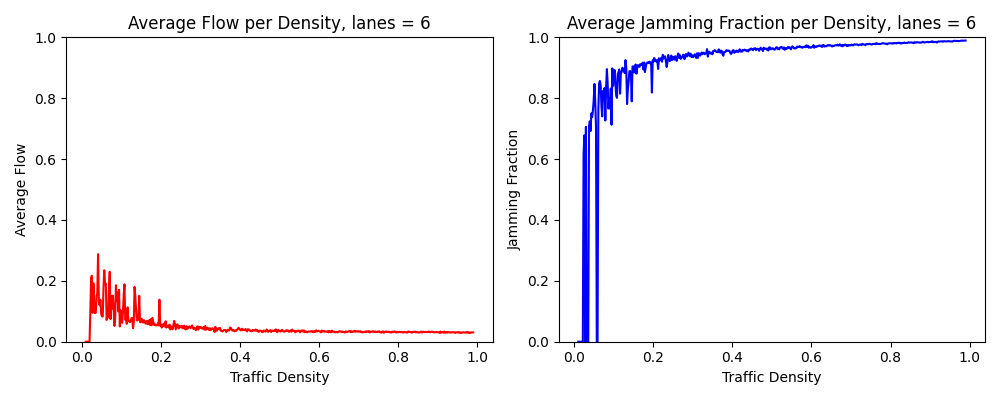

In [70]:


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))


axes[0].plot(density_range,average_flows, label = "Average Flow", color = 'red')
axes[0].set_title("Average Flow per Density, lanes = {}".format(lane_count))
axes[0].set_ylim(0,1)
axes[0].set_xlabel("Traffic Density")
axes[0].set_ylabel("Average Flow")

axes[1].plot(density_range,jamming_fractions, label = "Jamming Fraction", color = 'blue')
axes[1].set_title("Average Jamming Fraction per Density, lanes = {}".format(lane_count))
axes[1].set_ylim(0,1)
axes[1].set_xlabel("Traffic Density")
axes[1].set_ylabel("Jamming Fraction")

plt.tight_layout()
plt.show()

## Making a 3D Graph
For this part we varied the densiy as usual, but also introduced variations to the number of lanes.

In [39]:
cell_number = 100
jam_threshold = 0.2
density_range = np.linspace(0.01,0.99,300)
lane_range = range(1,33)
simulation_time = 500

density, lane = np.meshgrid(density_range,lane_range)

def stat_3d(density, lane):
    global pbar
    test_grid = Multi_Lane_Traffic(cells = cell_number, lanes = lane, density = density, vmax=5, random_state= 0, tolerance_limit= 1e-15)
    test_grid.simulate(simulation_time)
    pbar.update(1)
    return test_grid.history_jam_fraction(), test_grid.history_average_flow()

statistics_3d = np.vectorize(stat_3d)
with tqdm(total=len(lane_range)*len(density_range)) as pbar:
            jamming_fractions, average_flows = statistics_3d(density, lane)



9601it [09:25, 16.99it/s]                           


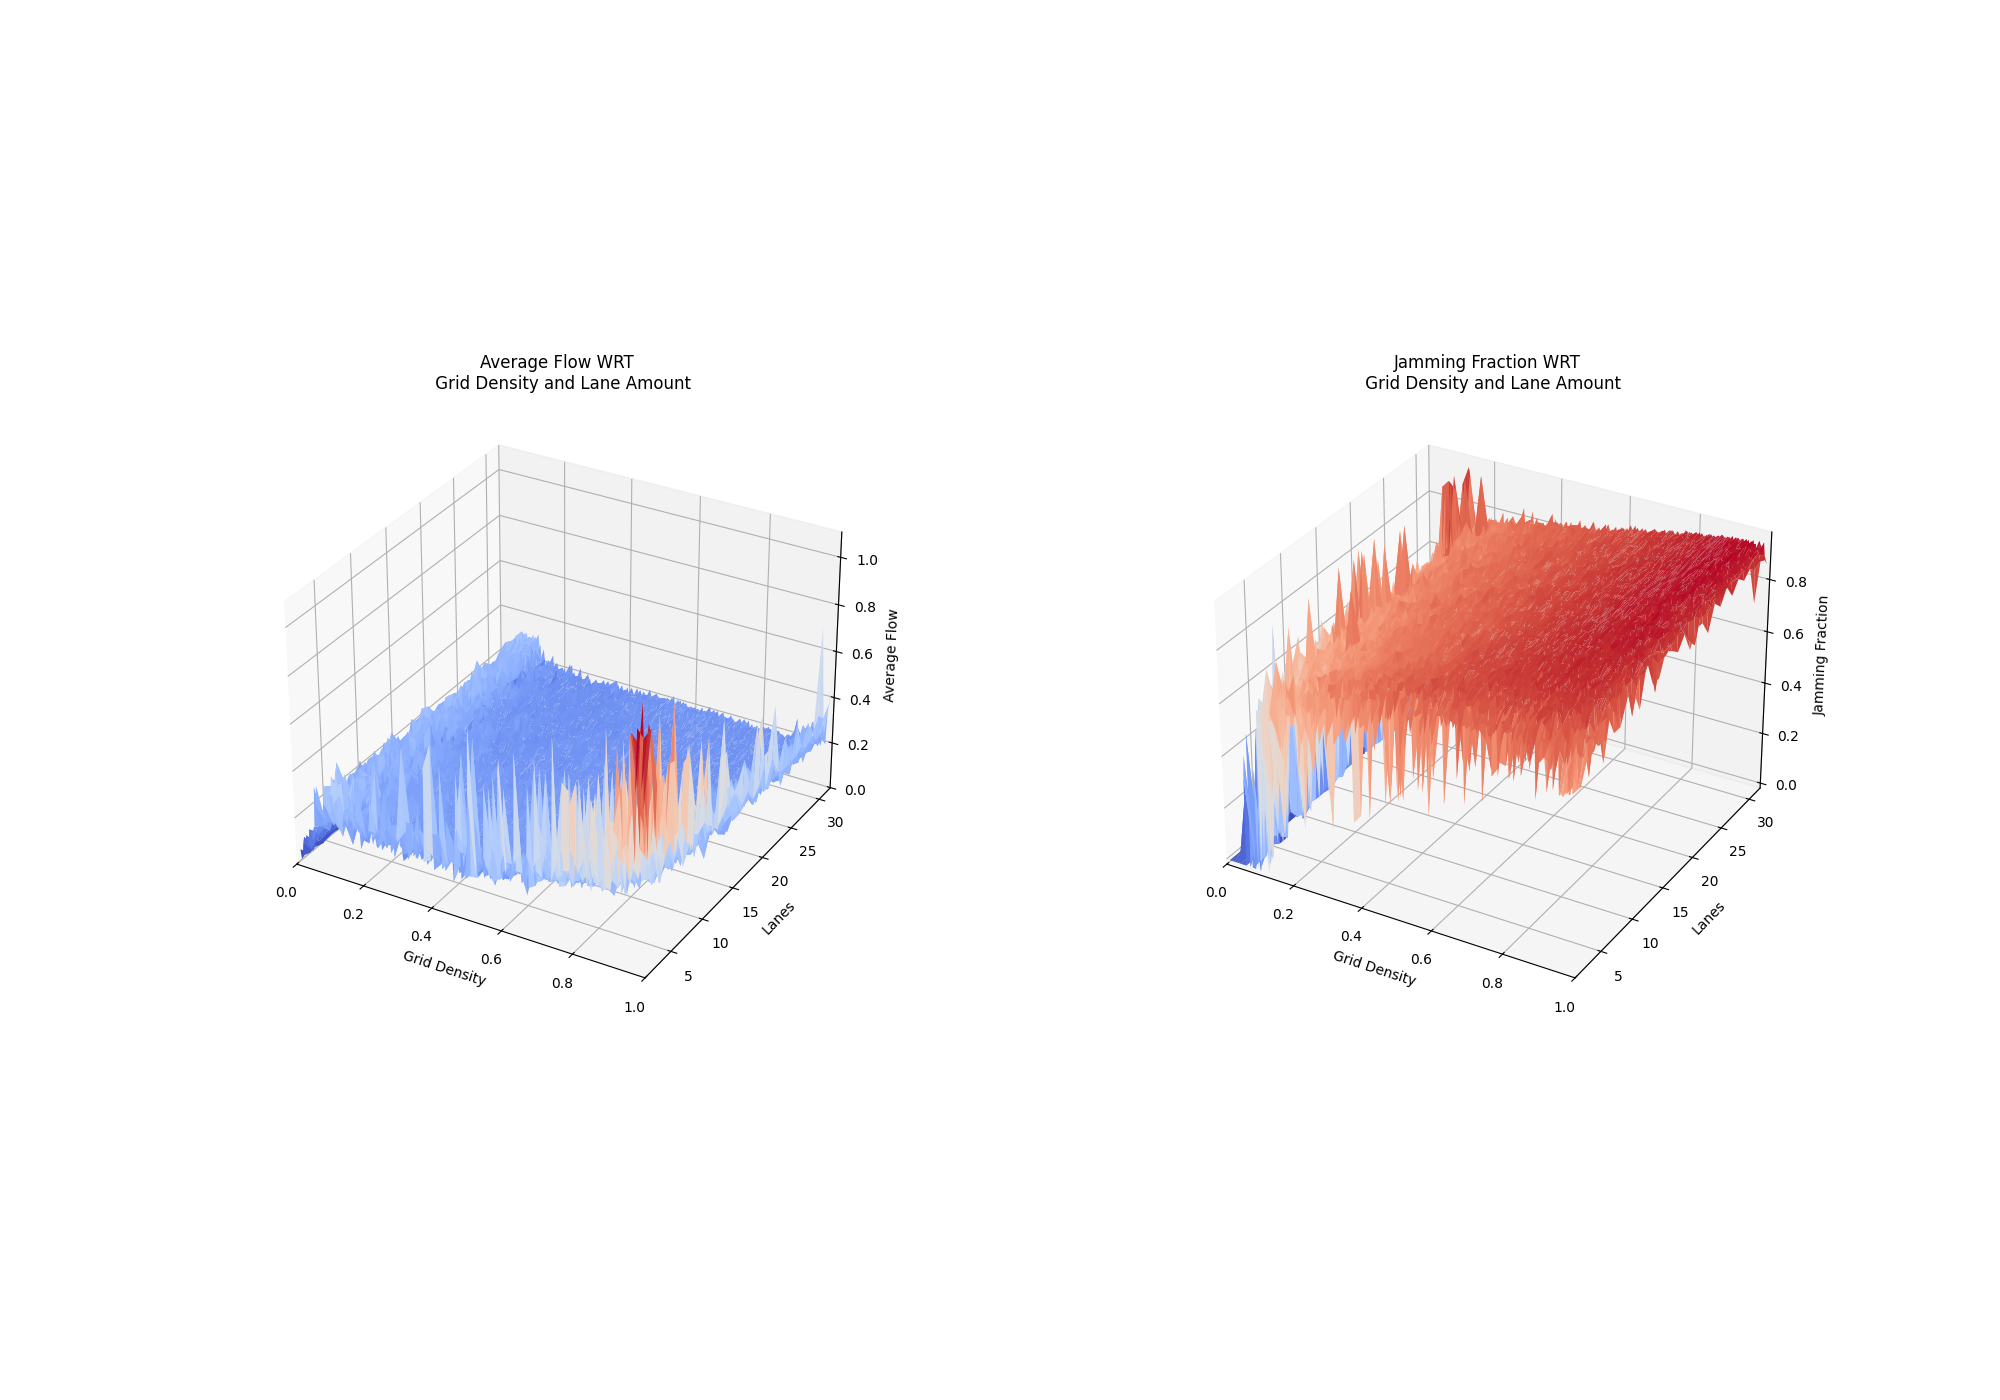

In [ ]:
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


fig = plt.figure(figsize=(20, 14))
ax = fig.add_subplot(122, projection='3d')


ay = fig.add_subplot(121, projection = '3d')

ay.plot_surface(density, lane, average_flows, rstride=1, cstride=1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=True)

ay.contourf(density, lane, average_flows, cmap=cm.coolwarm)

ay.set_xlabel('Grid Density')
ay.set_ylabel('Lanes')
ay.set_zlabel('Average Flow')
ay.set_title('Average Flow WRT \n Grid Density and Lane Amount')
ay.set_xlim(0,1)
ay.set_ylim(1,32)

ax.plot_surface(density, lane, jamming_fractions, rstride=1, cstride=1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=True)

ax.set_xlabel('Grid Density')
ax.set_ylabel('Lanes')
ax.set_zlabel('Jamming Fraction')
ax.set_title('Jamming Fraction WRT \n Grid Density and Lane Amount')
ax.set_xlim(0,1)
ax.set_ylim(1,32)


plt.subplots_adjust(wspace=0.5)
#plt.tight_layout()
plt.show()